#### Notebook character counter:

In [2]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}
    
    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())
    
    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f"{cell_type},{counts[cell_type]}")
    
    print(f"total,{total}")
    
    if total > 75000:
        print("Too many characters in assignment submission (> 75,000)")
    else:
        print("Number of characters ok ( < 75,000)")

count_chars('Task-1.ipynb')

code,1956
markdown,1145
raw,0
other,0
total,3101
Number of characters ok ( < 75,000)


## Table of Contents
1. [Introduction](#1-introduction)
2. [References](#2-references)
   1. [Python libraries used for assignment](#21-python-libraries-used-for-assignment)
3. [Setup and Initialization](#3-setup-and-initialization)
   1. [Load/Import the required Python libraries:](#31-loadimport-the-required-python-libraries)
   2. [Load the 3 datasets into individual pandas dataframes](#32-load-the-3-datasets-into-individual-pandas-dataframes)
   3. [Create Generic functions to be used by all datasets](#33-create-generic-functions-to-be-used-by-all-datasets)
4. [Evaluate Dataset 1](#4-evaluate-dataset-1)


## 1. Introduction

## 2. References

The following references are useful for the purpose of this assignment.

### 2.1 Python libraries used for assignment:

As part of the assignment, I have used the below listed Python libraries:

1. pandas - Python Data Analytics Library
   
    - https://pandas.pydata.org/

2. numpy - Scientific computing with Python

    - https://numpy.org/

3. missingno - Visualising missing data in dataframes

    - https://github.com/ResidentMario/missingno

4. scikit-learn - Machine Learning Library for Python

    - https://scikit-learn.org/stable/

5. matplotlib - Visualisation with Python

    - https://matplotlib.org/

6. seaborn - Statistical data visualisation

    - https://seaborn.pydata.org/

## 3. Setup and Initialization:

### 3.1 Load/Import the required Python libraries:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

# Data Visualization
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import figure

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

### 3.2 Load the 3 datasets into individual pandas dataframes

In [ ]:
import pandas as pd

# Set the display precision to 2
pd.set_option('display.precision', 2)

# Load 3 datasets into individual panda dataframes for further processing
df1 = pd.read_csv('CML_2026-01-26#4-dataset_1.csv')
df2 = pd.read_csv('CML_2026-01-26#5-dataset_2.csv')
df3 = pd.read_csv('CML_2026-01-26#6-dataset_3.csv')

### 3.3 Create Generic functions to be used by all datasets

In [ ]:
# Pandas tables display more neatly when precision is set to 2 decimal places.
pd.set_option('display.precision', 2)

def evaluate_model(model, X_train, X_test, Y_train, Y_test, model_name):
    # Calculate training time
    start_time = time.time()
    model.fit(X_train, Y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    # Calculate prediction time
    start_pred = time.time()
    Y_pred = model.predict(X_test)
    end_pred = time.time()
    prediction_time = end_pred - start_pred

    # Calculate evaluation metrics mean squared error and R^2 score
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    
    # Print results
    print(f"Model: {model_name}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Prediction time: {prediction_time:.2f} seconds")
    print("Classification Report:")
    #print(classification_report(Y_test, Y_pred))
    print("Confusion Matrix:")
    #print(confusion_matrix(Y_test, Y_pred))
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")

    return Y_pred 

## 4. Evaluate Dataset 1:

### 4.1 Analyse the data:

#### 4.1.1 Shape of the data:

In [ ]:
print(f"df1.shape = {df1.shape}")

df1.shape = (1001, 2)


#### 4.1.2 Info of the data:

In [5]:
print("df1.info =")
df1.info()

df1.info =
<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1001 non-null   int64  
 1   y       1001 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


#### 4.1.3 Plot Bar Charts:
Because `X` is a continuos variable with over 1000 points, a standard bar chart would be over cluttered. Instead, we will divide the `X` values in equal sized bins and calculate the mean `Y` value for each bin.

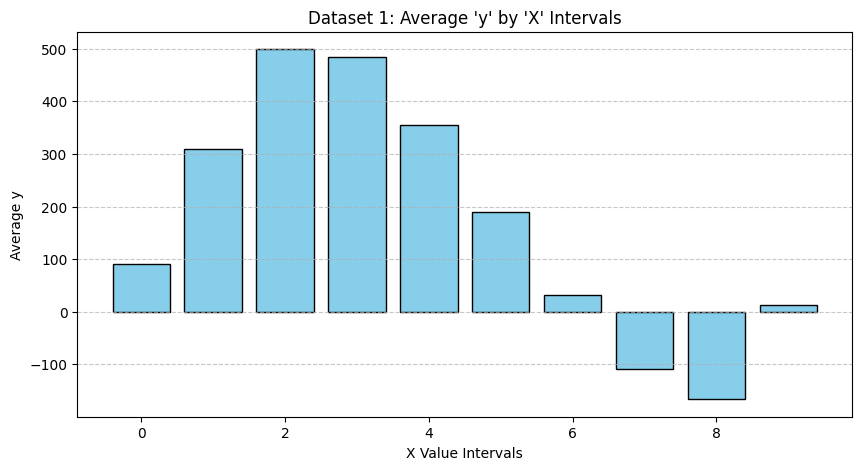

In [ ]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

# 2. Calculate the average 'y' for each bin
binned_data = df1.groupby('X_binned')['y'].mean().reset_index()

# 3. Create the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(binned_data.index, binned_data['y'], color='skyblue', edgecolor='black')


plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Seaborn Bar Chart**

/tmp/ipykernel_105344/3461970842.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_labels, rotation=45, ha='right')


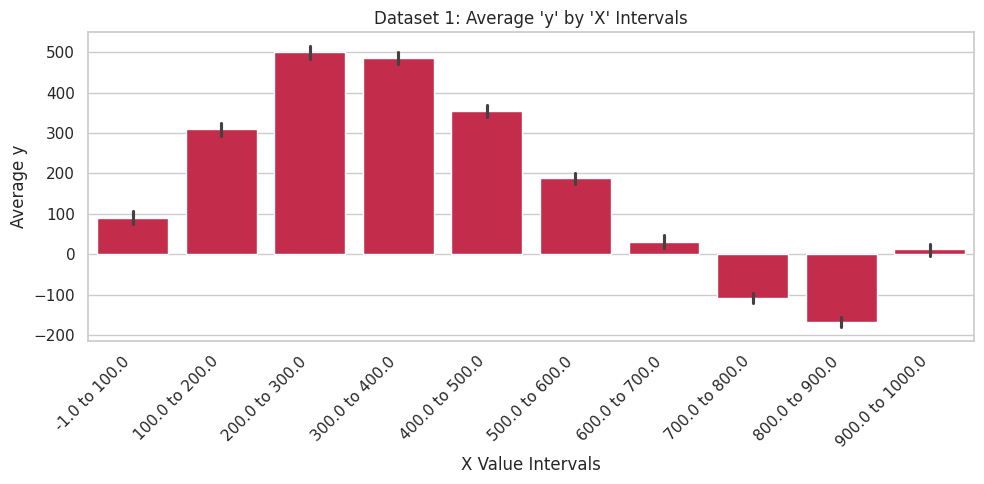

In [34]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df1, 
    x='X_binned', 
    y='y', 
    color='crimson',
    legend=False
)

bin_labels = [f"{interval.left:.1f} to {interval.right:.1f}" for interval in df1['X_binned'].cat.categories]
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.tight_layout()
plt.show()